
## Experiment: Evaluating the performance of the NTK, SAE and activation aggregation matrices on a labeling example

We are pulling data from the DBpedia 14 dataset and sampling 40 to 55 examples from each class. For this example we pulled 4 classes and will run through the NTK, SAE and activation aggregation matrices.
The point of this experiment is to see if we can use the NTK, SAE and activation aggregation matrices to cluster the prompts into the same class and measure their accuracies.
We are also trying out various ways to aggregate the tokens from different-sized prompts and report the results.
We are visualizing the resulting similarity matrices and reporting the results in the notebook.
This code requires an A10 80GB GPU to fit the model and Jacobian into the memory.
It also uses the sparse_autoencoder folder in this repository as installing via pip install git+https://github.com/openai/sparse_autoencoder.git was buggy and was not using the code from the above repository.

# Results:

Depending on the aggregation method, SAE is successful in clustering the prompts into the same class with varying degrees of success.
Using the methods with activations, we usually get very low accuracy, except for one aggregation method.
NTK's accuracy is usually lower than the SAE's accuracy, but generally performs better than the activation aggregation methods.

# Importing packages

In [1]:
import torch
import blobfile as bf
import transformer_lens
import sparse_autoencoder
import numpy as np
import matplotlib
import sklearn
from datasets import __version__ as datasets_version
import random
from datasets import load_dataset
import matplotlib.pyplot as plt
# Function to safely get version
def get_version(module):
    try:
        return module.__version__
    except AttributeError:
        try:
            return module.version.__version__
        except (AttributeError, ModuleNotFoundError):
            try:
                # Try to get version from package metadata
                import importlib.metadata
                return importlib.metadata.version(module.__name__)
            except (AttributeError, importlib.metadata.PackageNotFoundError):
                return "Version not available"

versions = {
    "torch": get_version(torch),
    "blobfile": get_version(bf),
    "transformer_lens": get_version(transformer_lens),
    "sparse_autoencoder": get_version(sparse_autoencoder),
    "numpy": get_version(np),
    "matplotlib": get_version(matplotlib),
    "sklearn": get_version(sklearn),
    "datasets": datasets_version
}

# Display in a formatted table
print("Package Versions:")
print("-" * 40)
for package, version in versions.items():
    print(f"{package:<20} {version}")
print("-" * 40)

/home/ubuntu/goodfire/test/test_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Package Versions:
----------------------------------------
torch                2.1.0+cu121
blobfile             2.0.2
transformer_lens     1.9.1
sparse_autoencoder   0.1
numpy                1.26.4
matplotlib           3.10.1
sklearn              1.6.1
datasets             3.4.1
----------------------------------------


# Load the dbpedia 14 dataset and sample 40 to 55 examples from each class
# Also shuffle the sampled examples.

In [19]:
dataset = load_dataset("dbpedia_14", split="train", streaming=False)
# Sample 4 examples from each class in AG News
sampled_prompts = []
label_descriptions = {
    4: "Office holder",
    8: "Village",
    10: "Plant",
    11: "Album"
}

# For reproducibility
random.seed(456546)

# Collect examples by label
examples_by_label = {4: [], 8: [], 10: [], 11: []}
for item in dataset:
    if item['label'] in [4, 8, 10, 11]:
        examples_by_label[item['label']].append(item)

num_samples_per_class = 40
true_labels = []
prompt_info = []  # To store (prompt, label) pairs

# Sample 4 from each label
i = 0
for label in [4, 8, 10, 11]:
    
    sample = random.sample(examples_by_label[label], num_samples_per_class + 5 * i)
    true_labels.extend([i] * len(sample))
    # Store each sample with its label
    for item in sample:
        prompt_info.append((item['content'], i))
    
    i += 1
    for item in sample:
        sampled_prompts.append(item['content'])
        # print(f"Label {label} ({label_descriptions[label]}): {item['content'][:100]}...")

sampled_prompts = []
true_labels = []

# Shuffle the combined data
random.seed(12345)  # Set seed for reproducibility
random.shuffle(prompt_info)

# Unpack the shuffled data
for prompt, label in prompt_info:
    sampled_prompts.append(prompt)
    true_labels.append(label)
    # print(f"Label {label}: length: {len(prompt)}")

print(f"Total samples: {len(sampled_prompts)}")
print(f"Class distribution: {np.bincount(true_labels)}")

# Calculate statistics on prompt lengths
prompt_lengths = [len(prompt) for prompt in sampled_prompts]

# Overall statistics
mean_length = np.mean(prompt_lengths)
std_length = np.std(prompt_lengths)
min_length = np.min(prompt_lengths)
max_length = np.max(prompt_lengths)

print(f"\nPrompt Length Statistics:")
print(f"Mean: {mean_length:.2f} characters")
print(f"Std Dev: {std_length:.2f} characters")
print(f"Min: {min_length} characters")
print(f"Max: {max_length} characters")

# Statistics per class
for class_id in range(4):
    class_lengths = [len(sampled_prompts[i]) for i, label in enumerate(true_labels) if label == class_id]
    class_mean = np.mean(class_lengths)
    class_std = np.std(class_lengths)
    label_name = list(label_descriptions.keys())[class_id]
    label_desc = label_descriptions[list(label_descriptions.keys())[class_id]]
    
    print(f"\nClass {class_id} ({label_desc}) Length Statistics:")
    print(f"Mean: {class_mean:.2f} characters")
    print(f"Std Dev: {class_std:.2f} characters")
    print(f"Min: {np.min(class_lengths)} characters")
    print(f"Max: {np.max(class_lengths)} characters")

Total samples: 190
Class distribution: [40 45 50 55]

Prompt Length Statistics:
Mean: 252.72 characters
Std Dev: 130.05 characters
Min: 33 characters
Max: 493 characters

Class 0 (Office holder) Length Statistics:
Mean: 302.77 characters
Std Dev: 117.95 characters
Min: 92 characters
Max: 490 characters

Class 1 (Village) Length Statistics:
Mean: 231.93 characters
Std Dev: 99.91 characters
Min: 33 characters
Max: 456 characters

Class 2 (Plant) Length Statistics:
Mean: 238.82 characters
Std Dev: 160.69 characters
Min: 47 characters
Max: 493 characters

Class 3 (Album) Length Statistics:
Mean: 245.96 characters
Std Dev: 119.44 characters
Min: 62 characters
Max: 488 characters


# Load up the transformer and autoencoder
# This part also has the function for the NTK computation with averagedcross entropy loss

In [3]:
# Import the model
model = transformer_lens.HookedTransformer.from_pretrained("gpt2", center_writing_weights=False, device="cuda")
device = next(model.parameters()).device


layer_index = 8
location = "resid_post_mlp"

transformer_lens_loc = {
    "mlp_post_act": f"blocks.{layer_index}.mlp.hook_post",
    "resid_delta_attn": f"blocks.{layer_index}.hook_attn_out",
    "resid_post_attn": f"blocks.{layer_index}.hook_resid_mid",
    "resid_delta_mlp": f"blocks.{layer_index}.hook_mlp_out",
    "resid_post_mlp": f"blocks.{layer_index}.hook_resid_post",
}[location]
# load the autoencoder
with bf.BlobFile(sparse_autoencoder.paths.v5_32k(location, layer_index), mode="rb") as f:
    state_dict = torch.load(f)
    autoencoder = sparse_autoencoder.Autoencoder.from_state_dict(state_dict)
    autoencoder.to(device)


# NTK computation for transformer models with averaged cross entropy loss
def compute_transformer_ntk(
    model,
    prompts,
    device=None
):
    """
    Compute the empirical NTK for a transformer model based on prompt-level loss,
    summing the losses for each token in the prompt.
    
    Args:
        model: The transformer model (transformer_lens HookedTransformer)
        prompts: List of text prompts
        device: Device to run computation on
        
    Returns:
        NTK matrix of shape (num_prompts, num_prompts)
    """
    if device is None:
        device = next(model.parameters()).device
    
    # Get the model parameters we care about
    parameters = [p for p in model.parameters() if p.requires_grad]
    n_params = sum(p.numel() for p in parameters)
    n_samples = len(prompts)
    
    # Initialize Jacobian - one row per prompt, one column per parameter
    jacobian = torch.zeros(n_samples, n_params, device=device, dtype=torch.bfloat16)
    
    for i, prompt in enumerate(prompts):
        print(f"Processing prompt {i+1} of {n_samples} for NTK")
        # Tokenize the prompt with an offset for calculating loss
        tokens = model.to_tokens(prompt, prepend_bos=True).to(device)
        
        # Target tokens are the input tokens shifted right 
        input_tokens = tokens[:, :-1]  # All tokens except the last one
        target_tokens = tokens[:, 1:]  # All tokens except the first one
        
        # Zero gradients before computation
        model.zero_grad()
        
        # Forward pass to get logits
        logits = model(input_tokens)
        
        # Compute loss - sum the cross-entropy loss for all tokens
        loss_fn = torch.nn.CrossEntropyLoss(reduction='mean')
        loss = loss_fn(logits.reshape(-1, logits.size(-1)), target_tokens.reshape(-1))
        loss = loss / len(tokens[0])
        # Compute gradient of loss with respect to model parameters
        loss.backward()
        
        # Extract gradients
        idx = 0
        for param in parameters:
            if param.grad is not None:
                grad_flatten = param.grad.flatten()
                jacobian[i, idx:idx+len(grad_flatten)] = grad_flatten
                idx += len(grad_flatten)
            else:
                # Some parameters might not be part of the computation graph
                idx += param.numel()
    
    # Compute the NTK matrix: K(x, x') = J(x) · J(x')^T
    ntk_matrix = jacobian @ jacobian.T
    return ntk_matrix.detach().cpu().float().numpy()

# --- Utility: Normalize a Matrix ---
def normalize_matrix(M: np.ndarray):
    M_tensor = torch.tensor(M, device=device)
    diag = torch.sqrt(torch.diag(M_tensor))
    norm_matrix = M_tensor / (diag.unsqueeze(1) * diag.unsqueeze(0) + 1e-8)
    return norm_matrix.detach().cpu().float().numpy()


Loaded pretrained model gpt2 into HookedTransformer


In [4]:
# helpher function for plotting small matrices
def plot_matrix(normalized_ntk_matrix, normalized_sae_graph, normalized_activation_aggregation_graph, title):
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
    # Find global min and max values across both matrices for consistent coloring
    global_min = min(normalized_ntk_matrix.min(), normalized_sae_graph.min())
    global_max = max(normalized_ntk_matrix.max(), normalized_sae_graph.max())
    
    # Use the same colormap for both plots
    cmap = 'viridis'
    
    # Plot NTK Matrix with shared range
    im1 = ax1.imshow(normalized_ntk_matrix, cmap=cmap, vmin=global_min, vmax=global_max)
    ax1.set_title('Normalized NTK Matrix')
    
    # Add text annotations with values
    for i in range(normalized_ntk_matrix.shape[0]):
        for j in range(normalized_ntk_matrix.shape[1]):
            value = normalized_ntk_matrix[i, j]
            # Adjust text color based on middle of range
            color = 'white' if value < (global_min + global_max)/2 else 'black'
            ax1.text(j, i, f'{value:.2f}', ha='center', va='center', 
                    color=color, fontsize=8)
    
    # Create a colorbar with the shared range
    cbar1 = plt.colorbar(im1, ax=ax1)
    
    # Plot Latent Activations Matrix with same shared range
    im3 = ax3.imshow(normalized_activation_aggregation_graph, cmap=cmap, vmin=global_min, vmax=global_max)
    ax3.set_title('Normalized Activation Aggregation Matrix')
    
    # Create a colorbar with the shared range
    cbar3 = plt.colorbar(im3, ax=ax3)
    # Add text annotations with values
    for i in range(normalized_activation_aggregation_graph.shape[0]):
        for j in range(normalized_activation_aggregation_graph.shape[1]):
            value = normalized_activation_aggregation_graph[i, j]
            # Adjust text color based on middle of range
            color = 'white' if value < (global_min + global_max)/2 else 'black'
            ax3.text(j, i, f'{value:.2f}', ha='center', va='center', 
                    color=color, fontsize=8)
    
    # Plot SAE Matrix with same shared range
    im2 = ax2.imshow(normalized_sae_graph, cmap=cmap, vmin=global_min, vmax=global_max)
    ax2.set_title('Normalized SAE Matrix')
    
    # Add text annotations with values
    for i in range(normalized_sae_graph.shape[0]):
        for j in range(normalized_sae_graph.shape[1]):
            value = normalized_sae_graph[i, j]
            # Adjust text color based on middle of range
            color = 'white' if value < (global_min + global_max)/2 else 'black'
            ax2.text(j, i, f'{value:.2f}', ha='center', va='center', 
                    color=color, fontsize=8)
    
    # Create a colorbar with the shared range
    cbar2 = plt.colorbar(im2, ax=ax2)
    
    # Add labels for reference
    prompt_labels = [f"Prompt {i+1}" for i in range(len(sampled_prompts))]
    
    # Set ticks and labels for NTK matrix
    ax1.set_xticks(np.arange(len(prompt_labels)))
    ax1.set_yticks(np.arange(len(prompt_labels)))
    ax1.set_xticklabels(prompt_labels)
    ax1.set_yticklabels(prompt_labels)
    plt.setp(ax1.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
    # Set ticks and labels for SAE matrix
    ax2.set_xticks(np.arange(len(prompt_labels)))
    ax2.set_yticks(np.arange(len(prompt_labels)))
    ax2.set_xticklabels(prompt_labels)
    ax2.set_yticklabels(prompt_labels)
    plt.setp(ax2.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    

     # Add a global title to the figure
    fig.suptitle(title, fontsize=16, y=0.98)
    
    # Adjust the layout to make room for the title
    plt.tight_layout(rect=[0, 0.03, 1, 0.93])  # Adjusted top margin for the title
    # plt.savefig(f"{title}.png")

# Compute the NTK matrix

In [5]:
test_prompts = sampled_prompts

# Ensure model is in evaluation mode but allows gradient computation
model.eval()
for param in model.parameters():
    param.requires_grad = True

# Compute the NTK matrix
ntk_matrix = compute_transformer_ntk(
    model=model,
    prompts=test_prompts
)


Processing prompt 1 of 190 for NTK
Processing prompt 2 of 190 for NTK
Processing prompt 3 of 190 for NTK
Processing prompt 4 of 190 for NTK
Processing prompt 5 of 190 for NTK
Processing prompt 6 of 190 for NTK
Processing prompt 7 of 190 for NTK
Processing prompt 8 of 190 for NTK
Processing prompt 9 of 190 for NTK
Processing prompt 10 of 190 for NTK
Processing prompt 11 of 190 for NTK
Processing prompt 12 of 190 for NTK
Processing prompt 13 of 190 for NTK
Processing prompt 14 of 190 for NTK
Processing prompt 15 of 190 for NTK
Processing prompt 16 of 190 for NTK
Processing prompt 17 of 190 for NTK
Processing prompt 18 of 190 for NTK
Processing prompt 19 of 190 for NTK
Processing prompt 20 of 190 for NTK
Processing prompt 21 of 190 for NTK
Processing prompt 22 of 190 for NTK
Processing prompt 23 of 190 for NTK
Processing prompt 24 of 190 for NTK
Processing prompt 25 of 190 for NTK
Processing prompt 26 of 190 for NTK
Processing prompt 27 of 190 for NTK
Processing prompt 28 of 190 for NTK
P

# Compute the sae features and activations

In [6]:
# num features for decoeder and activations
num_features = autoencoder.decoder.weight.shape[1]
num_activations = autoencoder.decoder.weight.shape[0]
# Initialize dicts for raw activations and features
model_activations_matrix = {}
model_features_matrix = {}
# Initialize matrices for aggregated activations and features
sae_aggregation_matrix = torch.zeros(len(test_prompts), num_features, device=device, dtype=torch.bfloat16)
activation_aggregation_matrix = torch.zeros(len(test_prompts), num_activations, device=device, dtype=torch.bfloat16)

for i, prompt in enumerate(test_prompts):
    print(f"Processing prompt {i+1} of {len(test_prompts)} for SAE")
    tokens = model.to_tokens(prompt)  # (1, n_tokens)
    with torch.no_grad():
        logits, activation_cache = model.run_with_cache(tokens, remove_batch_dim=True)

    input_tensor = activation_cache[transformer_lens_loc]
    
    # Process all tokens in the prompt
    with torch.no_grad():
        latent_activations, info = autoencoder.encode(input_tensor)
        
        model_activations_matrix[i] = input_tensor
        model_features_matrix[i] = latent_activations
        
        

Processing prompt 1 of 190 for SAE
Processing prompt 2 of 190 for SAE
Processing prompt 3 of 190 for SAE
Processing prompt 4 of 190 for SAE
Processing prompt 5 of 190 for SAE
Processing prompt 6 of 190 for SAE
Processing prompt 7 of 190 for SAE
Processing prompt 8 of 190 for SAE
Processing prompt 9 of 190 for SAE
Processing prompt 10 of 190 for SAE
Processing prompt 11 of 190 for SAE
Processing prompt 12 of 190 for SAE
Processing prompt 13 of 190 for SAE
Processing prompt 14 of 190 for SAE
Processing prompt 15 of 190 for SAE
Processing prompt 16 of 190 for SAE
Processing prompt 17 of 190 for SAE
Processing prompt 18 of 190 for SAE
Processing prompt 19 of 190 for SAE
Processing prompt 20 of 190 for SAE
Processing prompt 21 of 190 for SAE
Processing prompt 22 of 190 for SAE
Processing prompt 23 of 190 for SAE
Processing prompt 24 of 190 for SAE
Processing prompt 25 of 190 for SAE
Processing prompt 26 of 190 for SAE
Processing prompt 27 of 190 for SAE
Processing prompt 28 of 190 for SAE
P

# helper function for computing matrix statistics

In [7]:

def compute_matrix_statistics(matrix, name):
    """Compute various statistics for a given matrix."""
    # Basic statistics
    basic_stats = {
        "Name": name,
        "Shape": matrix.shape,
        "Min": matrix.min(),
        "Max": matrix.max(),
        "Mean": matrix.mean(),
        "Median": np.median(matrix),
        "Std Dev": matrix.std(),
    }

    return basic_stats

def analyze_matrices(matrices):
    for name, matrix in matrices.items():
        stats = compute_matrix_statistics(matrix, name)
        
        print(f"\n{'-'*20} {name} Statistics {'-'*20}")
        for key, value in stats.items():
            print(f"{key}: {value}")
        
        # Additional inter-matrix statistics
        if name != "SAE Similarity":
            correlation = np.corrcoef(matrices["SAE Similarity"].flatten(), matrix.flatten())[0, 1]
            print(f"Correlation with SAE Matrix: {correlation:.4f}")
            
            # Element-wise differences
            element_diffs = matrices["SAE Similarity"] - matrix
            print(f"Mean Absolute Difference from SAE: {np.abs(element_diffs).mean():.4f}")
            print(f"Max Absolute Difference from SAE: {np.abs(element_diffs).max():.4f}")
            print(f"RMS Difference from SAE: {np.sqrt((element_diffs**2).mean()):.4f}")

    # Block structure analysis
    for name, matrix in matrices.items():
        print(f"\n{'-'*20} Block Structure Analysis for {name} {'-'*20}")
        block_size = matrix.shape[0] // 4  # Assuming 4 clusters
        
        # Analyze within-block vs between-block similarities
        within_block_values = []
        between_block_values = []
        
        for i in range(4):
            for j in range(4):
                block = matrix[i*block_size:(i+1)*block_size, j*block_size:(j+1)*block_size]
                if i == j:  # Within-block
                    within_block_values.extend(block.flatten())
                else:  # Between-block
                    between_block_values.extend(block.flatten())
        
        within_mean = np.mean(within_block_values)
        between_mean = np.mean(between_block_values)
        
        print(f"Within-block mean similarity: {within_mean:.4f}")
        print(f"Between-block mean similarity: {between_mean:.4f}")
        print(f"Block structure strength ratio (within/between): {within_mean/between_mean:.4f}")

# methods for clustering and evaluating the results

In [8]:
from sklearn.cluster import SpectralClustering
from sklearn.metrics import adjusted_rand_score, silhouette_score
import pandas as pd
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, confusion_matrix
from scipy.optimize import linear_sum_assignment



def cluster_with_spectral(similarity_matrix, n_clusters=4):
    # Create a fully cleaned copy
    similarity_matrix_copy = similarity_matrix.copy()
    
    # Set diagonal to ones (or zeros)
    np.fill_diagonal(similarity_matrix_copy, 1.0)
    
    # Replace any NaNs with zeros
    similarity_matrix_copy = np.nan_to_num(similarity_matrix_copy, nan=0.0)
    
    # Ensure matrix is symmetric
    similarity_matrix_copy = 0.5 * (similarity_matrix_copy + similarity_matrix_copy.T)
    
    # Ensure all values are in valid range (0-1 for similarity)
    similarity_matrix_copy = np.clip(similarity_matrix_copy, 0, 1)
    
    # Final check for NaNs
    assert not np.isnan(similarity_matrix_copy).any(), "Matrix still contains NaNs!"
    
    # Now try spectral clustering
    spectral = SpectralClustering(
        n_clusters=n_clusters,
        random_state=42,
        affinity='precomputed',
        assign_labels='discretize'
    )
    cluster_labels = spectral.fit_predict(similarity_matrix_copy)
    
    # Fill diagonal with zeros for silhouette calculation
    np.fill_diagonal(similarity_matrix_copy, 0)
    
    # Convert similarity to distance matrix (ensure non-negative values)
    # Method 1: Convert to distance by taking 1 - normalized similarity
    # First normalize to [0,1] range
    min_val = similarity_matrix_copy.min()
    max_val = similarity_matrix_copy.max()
    normalized = (similarity_matrix_copy - min_val) / (max_val - min_val + 1e-8)
    
    # Make sure diagonal remains zero after normalization
    np.fill_diagonal(normalized, 0)
    
    # Convert to distance (higher similarity = lower distance)
    distance_matrix = 1 - normalized
    
    # Ensure diagonal is still zero in the final distance matrix
    np.fill_diagonal(distance_matrix, 0)
    
    # Calculate silhouette score
    silhouette = silhouette_score(distance_matrix, cluster_labels, metric='precomputed')
    
    return cluster_labels, silhouette

def evaluate_clustering(predicted_clusters, true_labels=None):
    """
    Evaluate clustering results against true labels or expected grouping pattern.
    
    Args:
        predicted_clusters: Array of predicted cluster assignments
        true_labels: Array of true class labels. If None, will use the pattern [0,0,0,0,1,1,1,1,...] based on 4 samples per class
        
    Returns:
        Dictionary with evaluation metrics
    """
    # If no true labels provided, create them based on 4 samples per group pattern
    if true_labels is None:
        # Assume 4 samples per class in order
        true_labels = np.array([i//num_samples_per_class for i in range(len(predicted_clusters))])
    
    # Standard clustering metrics (invariant to label permutation)
    ari = adjusted_rand_score(true_labels, predicted_clusters)
    nmi = normalized_mutual_info_score(true_labels, predicted_clusters)
    
    # Find optimal label mapping for accuracy calculation
    # This handles the case where cluster IDs are arbitrary
    cm = confusion_matrix(true_labels, predicted_clusters)
    row_ind, col_ind = linear_sum_assignment(-cm)  # Maximize overlap
    
    # Create remapped predictions using optimal assignment
    remapped_predictions = np.zeros_like(predicted_clusters)
    for i, j in zip(row_ind, col_ind):
        mask = (predicted_clusters == j)
        remapped_predictions[mask] = i
    
    # Calculate accuracy after optimal mapping
    accuracy = np.sum(remapped_predictions == true_labels) / len(true_labels)
    
    # Create confusion matrix for display
    relabeled_cm = confusion_matrix(true_labels, remapped_predictions)
    
    return {
        "ARI": ari,
        "NMI": nmi,
        "Remapped Accuracy": accuracy,
        "Remapped Predictions": remapped_predictions,
        "Confusion Matrix": relabeled_cm
    }
        


def plot_clustered_matrices(matrices, cluster_assignments, true_labels):
    """
    Three-part visualization:
    1. Each similarity matrix reordered by its own clustering method
    2. A single confusion matrix with metrics for each clustering method
    3. A summary metrics comparison chart
    
    Args:
        matrices: Dictionary of {name: matrix} pairs
        cluster_assignments: Dictionary of {method_name: cluster_labels} pairs
        true_labels: Array of ground truth labels
    """
    # Part 1: Plot each matrix reordered by its own clustering method
    fig, axes = plt.subplots(1, len(matrices), figsize=(6*len(matrices), 5))
    fig.suptitle(f"Similarity Matrices Reordered by Their Respective Clustering Methods", fontsize=16)
    
    if len(matrices) == 1:
        axes = [axes]  # Convert to list for consistent indexing
    
    # Match matrix names with clustering method names
    matrix_to_method = {
        "SAE Similarity": "SAE Spectral",
        "Activation Similarity": "Activation Spectral", 
        "NTK Similarity": "NTK Spectral"
    }
    
    # For each matrix
    for i, (matrix_name, matrix) in enumerate(matrices.items()):
        ax = axes[i]
        
        # Get corresponding clustering method
        method_name = matrix_to_method.get(matrix_name)
        if method_name not in cluster_assignments:
            # Fallback if no exact match
            print(f"Warning: No exact method match for {matrix_name}, using first available clustering")
            method_name = list(cluster_assignments.keys())[0]
            
        clusters = cluster_assignments[method_name]
        
        # Get indices that would sort by cluster assignment
        sorted_indices = np.argsort(clusters)
        
        # Get evaluation metrics
        eval_results = evaluate_clustering(clusters, true_labels)
        accuracy = eval_results['Remapped Accuracy']
        ari = eval_results['ARI']
        nmi = eval_results['NMI']
        
        # Reorder matrix by cluster assignments
        reordered_matrix = matrix[sorted_indices][:, sorted_indices]
        
        # Plot heatmap
        im = ax.imshow(reordered_matrix, cmap='viridis')
        ax.set_title(f"{matrix_name}\nClustered by {method_name}", fontsize=12)
        
        # Add colorbar
        plt.colorbar(im, ax=ax)
        
        # Add cluster boundaries
        cluster_bounds = []
        prev_cluster = clusters[sorted_indices[0]]
        for idx, cluster in enumerate(clusters[sorted_indices]):
            if cluster != prev_cluster:
                cluster_bounds.append(idx)
                prev_cluster = cluster
        
        # Draw lines to show cluster boundaries
        for bound in cluster_bounds:
            ax.axhline(y=bound-0.5, color='r', linestyle='-', linewidth=1)
            ax.axvline(x=bound-0.5, color='r', linestyle='-', linewidth=1)
        
        # Add metric summary under each plot
        ax.text(0.5, -0.15, 
              f"Accuracy: {accuracy:.3f}, ARI: {ari:.3f}, NMI: {nmi:.3f}",
              ha="center", transform=ax.transAxes, fontsize=10, 
              bbox={"facecolor":"orange", "alpha":0.2, "pad":5})
    
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()
    
    # Part 2: Plot all confusion matrices side by side
    n_methods = len(cluster_assignments)
    fig, axes = plt.subplots(1, n_methods, figsize=(5*n_methods, 5))
    fig.suptitle("Confusion Matrices for Different Clustering Methods", fontsize=16)
    
    if n_methods == 1:
        axes = [axes]  # Convert to list for consistent indexing
    
    for i, (method_name, clusters) in enumerate(cluster_assignments.items()):
        ax = axes[i]
        
        # Get evaluation metrics
        eval_results = evaluate_clustering(clusters, true_labels)
        accuracy = eval_results['Remapped Accuracy']
        ari = eval_results['ARI']
        nmi = eval_results['NMI']
        cm = eval_results['Confusion Matrix']
        
        # Plot confusion matrix
        im = ax.imshow(cm, cmap='Blues')
        
        # Set title with method name and metrics
        title = f"{method_name}\nAcc: {accuracy:.3f}, ARI: {ari:.3f}, NMI: {nmi:.3f}"
        ax.set_title(title, fontsize=12)
        
        # Add labels
        ax.set_xlabel("Predicted Class")
        ax.set_ylabel("True Class")
        
        # Configure ticks
        n_classes = len(np.unique(true_labels))
        ax.set_xticks(np.arange(n_classes))
        ax.set_yticks(np.arange(n_classes))
        ax.set_xticklabels(np.arange(n_classes))
        ax.set_yticklabels(np.arange(n_classes))
        
        # Add text annotations to confusion matrix
        thresh = cm.max() / 2
        for i_cm in range(cm.shape[0]):
            for j_cm in range(cm.shape[1]):
                # Calculate percentage of row total
                row_total = np.sum(cm[i_cm, :])
                percentage = cm[i_cm, j_cm] / row_total * 100 if row_total > 0 else 0
                
                # Set text color based on cell darkness
                color = "white" if cm[i_cm, j_cm] > thresh else "black"
                
                # Show count and percentage
                text = f"{cm[i_cm, j_cm]}\n({percentage:.1f}%)"
                ax.text(j_cm, i_cm, text,
                        ha="center", va="center", color=color, fontsize=10)
                        
        plt.colorbar(im, ax=ax)
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()



# helper function for normalizing and computing clusters, and also runs the plot methods

In [9]:
def normalize_and_compute_clusters(sae_aggregation_matrix, activation_aggregation_matrix, ntk_matrix):
    # Compute the SAE dependency graph (similarity matrix between prompts)
    sae_dependency_graph = (sae_aggregation_matrix @ sae_aggregation_matrix.T).cpu().float().numpy()
    activation_aggregation_dependency_graph = (activation_aggregation_matrix @ activation_aggregation_matrix.T).cpu().float().numpy()
    normalized_sae_graph = normalize_matrix(sae_dependency_graph)
    normalized_ntk_matrix = normalize_matrix(ntk_matrix)
    normalized_activation_aggregation_graph = normalize_matrix(activation_aggregation_dependency_graph)


    # Compute statistics for each matrix
    matrices = {
        "SAE Similarity": normalized_sae_graph,
        "Activation Similarity": normalized_activation_aggregation_graph,
        "NTK Similarity": normalized_ntk_matrix
    }


    # Cluster using spectral clustering on the similarity matrices
    sae_spectral_clusters, sae_spectral_silhouette = cluster_with_spectral(
        normalized_sae_graph, n_clusters=4
    )

    act_spectral_clusters, act_spectral_silhouette = cluster_with_spectral(
        normalized_activation_aggregation_graph, n_clusters=4
    )

    ntk_spectral_clusters, ntk_spectral_silhouette = cluster_with_spectral(
        normalized_ntk_matrix, n_clusters=4
    )

    methods = {
        "SAE Spectral": (sae_spectral_clusters, sae_spectral_silhouette),
        "Activation Spectral": (act_spectral_clusters, act_spectral_silhouette),
        "NTK Spectral": (ntk_spectral_clusters, ntk_spectral_silhouette),
        "Random": (np.random.randint(0, 4, size=len(test_prompts)), 0)
    }
    # After running your clustering code:
    matrices = {
        "SAE Similarity": normalized_sae_graph,
        "Activation Similarity": normalized_activation_aggregation_graph,
        "NTK Similarity": normalized_ntk_matrix
    }

    cluster_assignments = {
        "SAE Spectral": sae_spectral_clusters,
        "Activation Spectral": act_spectral_clusters,
        "NTK Spectral": ntk_spectral_clusters
    }

    plot_clustered_matrices(matrices, cluster_assignments, true_labels)


# Results with taking the maximum over each feature and activation values over the tokens.
# SAE has a very high accuracy, but the activation aggregation methods have a very low accuracy.
# NTK's accuracy is about 81%, and we plot the similarity matrices reodered by the spectral clustering for each methods.

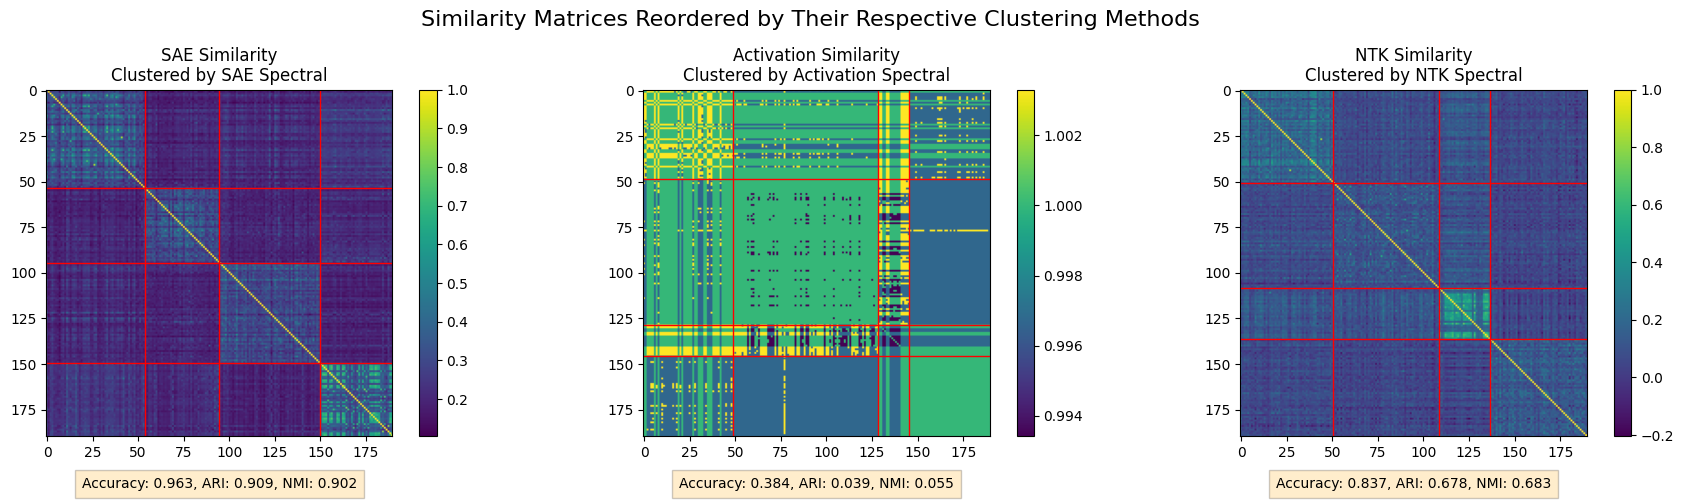

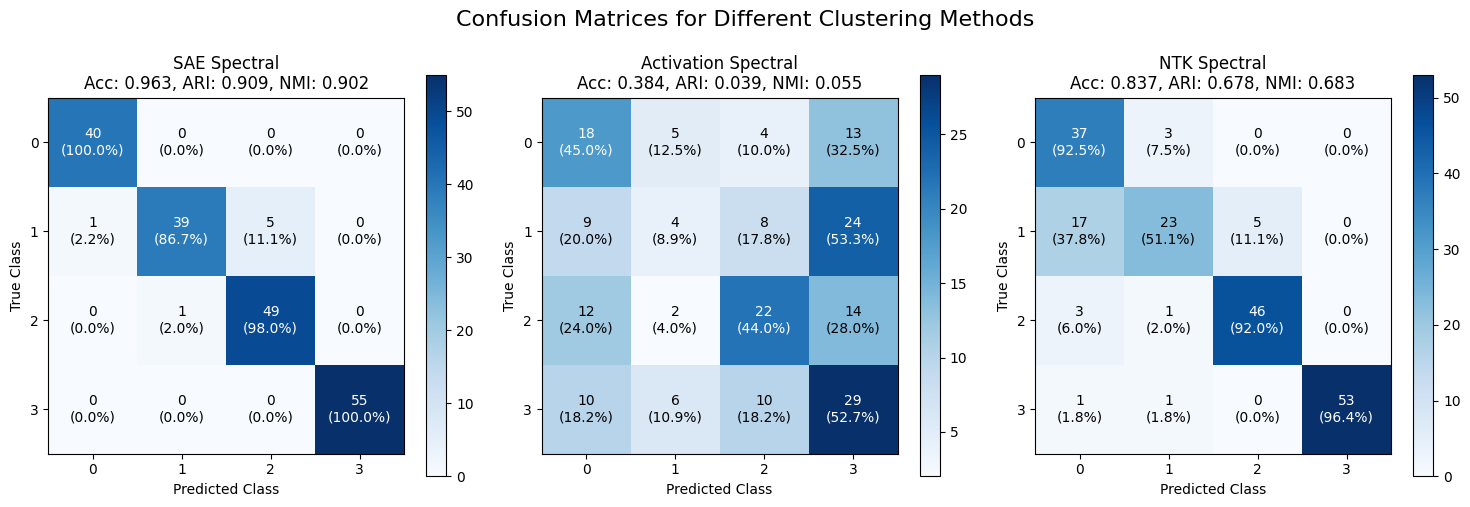

In [10]:
for i, prompt in enumerate(test_prompts):
    sae_aggregation_matrix[i] = model_features_matrix[i].amax(dim=0)
    activation_aggregation_matrix[i] = model_activations_matrix[i].amax(dim=0)
    
normalize_and_compute_clusters(sae_aggregation_matrix, activation_aggregation_matrix, ntk_matrix)
    



# Results with taking the mean over each feature and activation values over the tokens.
# SAE's accuracy is lower, and activation performance is better compared to the maximum case.

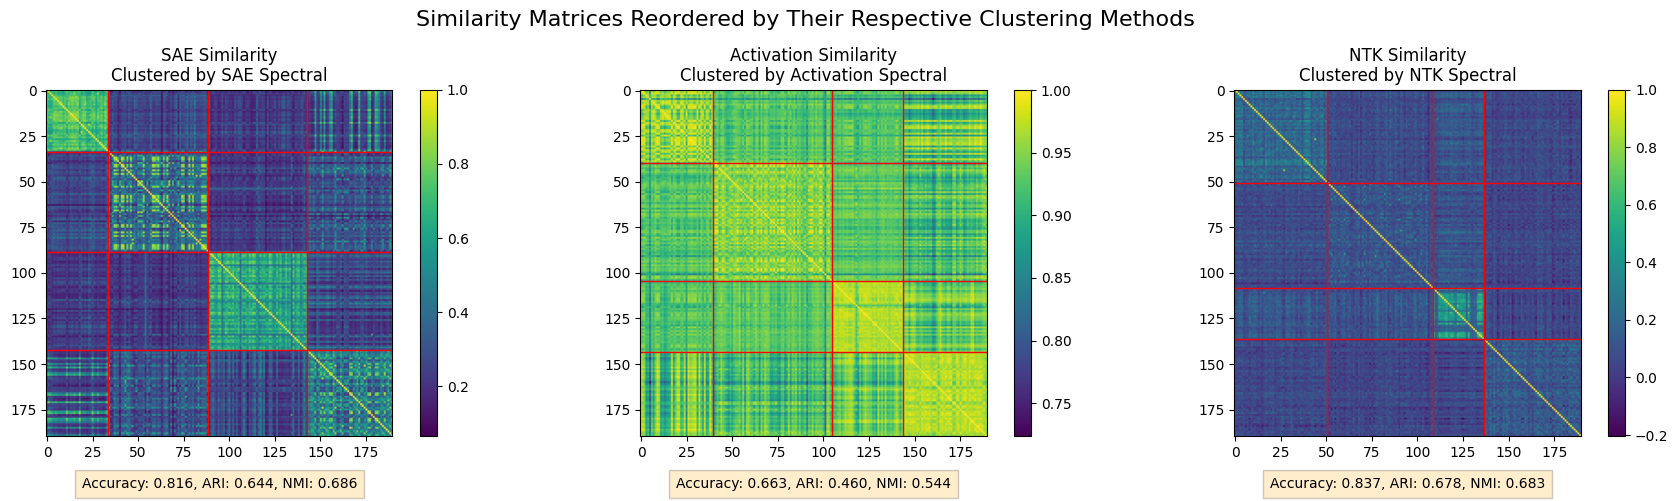

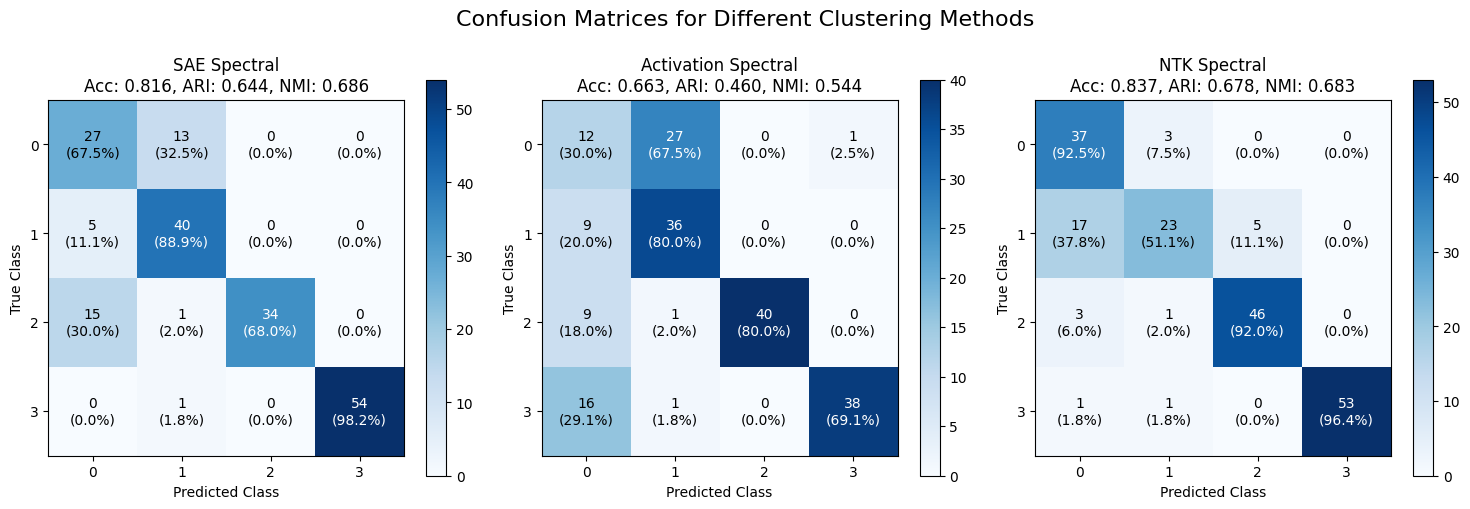

In [11]:
for i, prompt in enumerate(test_prompts):

    sae_aggregation_matrix[i] = model_features_matrix[i].mean(dim=0)
    activation_aggregation_matrix[i] = model_activations_matrix[i].mean(dim=0)
    
normalize_and_compute_clusters(sae_aggregation_matrix, activation_aggregation_matrix, ntk_matrix)

# This method first normalizes the features and activations, and then takes the maximum over the tokens.
# For this case, both of the SAE's and activations's accuracy is very high.
# However, there's very little variance in the activation similarity matrix.

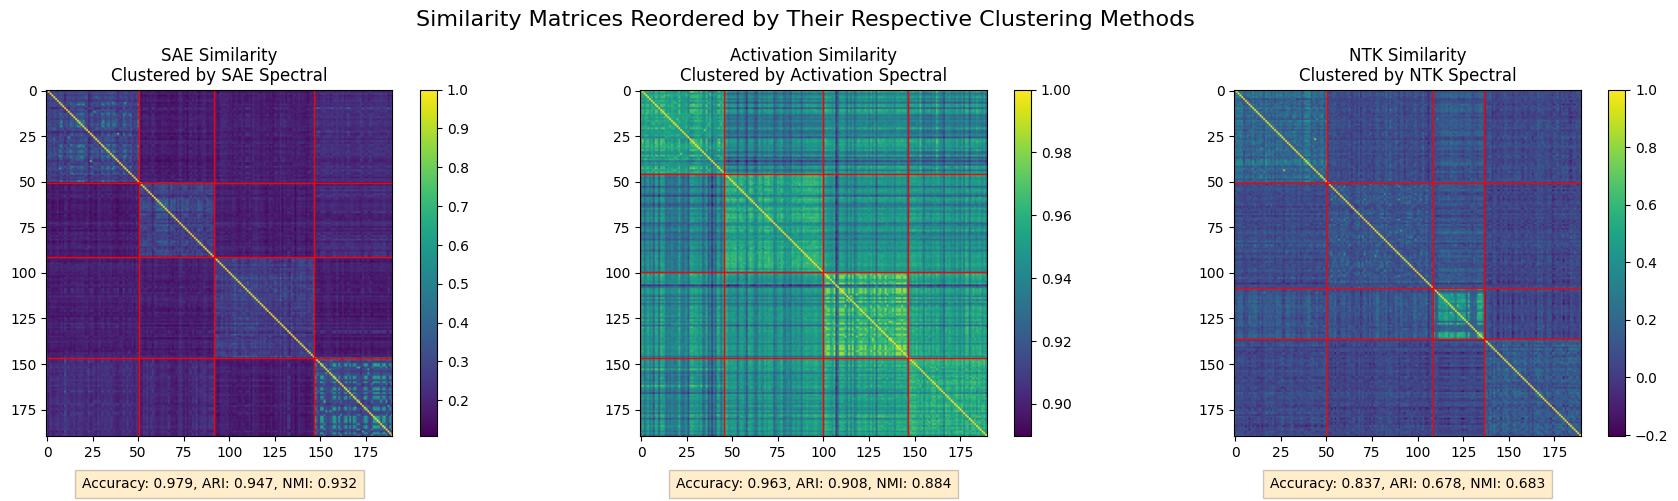

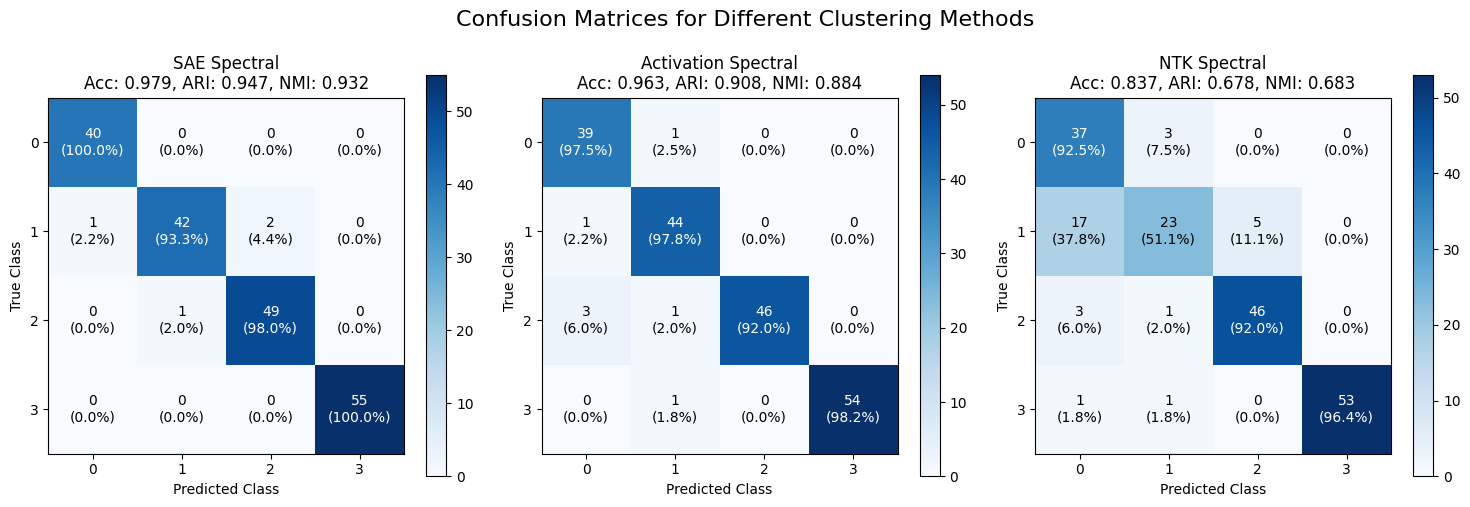

In [12]:
for i, prompt in enumerate(test_prompts):
    sae_aggregation_matrix[i] = torch.nn.functional.normalize(model_features_matrix[i], p=2, dim=0).amax(dim=0)
    activation_aggregation_matrix[i] = torch.nn.functional.normalize(model_activations_matrix[i], p=2, dim=0).amax(dim=0)

normalize_and_compute_clusters(sae_aggregation_matrix, activation_aggregation_matrix, ntk_matrix)

# This method first normalizes the features and activations, and then takes the mean over the tokens.
# For this case, both of the SAE's and activations's accuracy is very high.
# There's also a lot of visible variance in the SAE and activation similarity matrices.

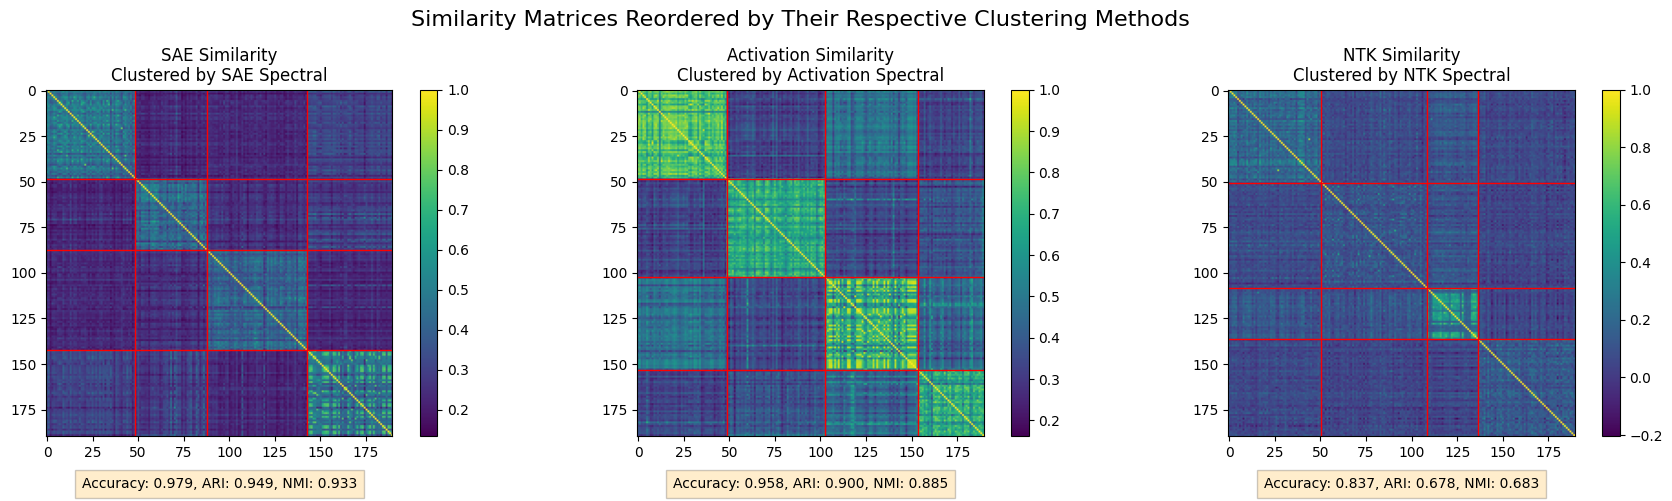

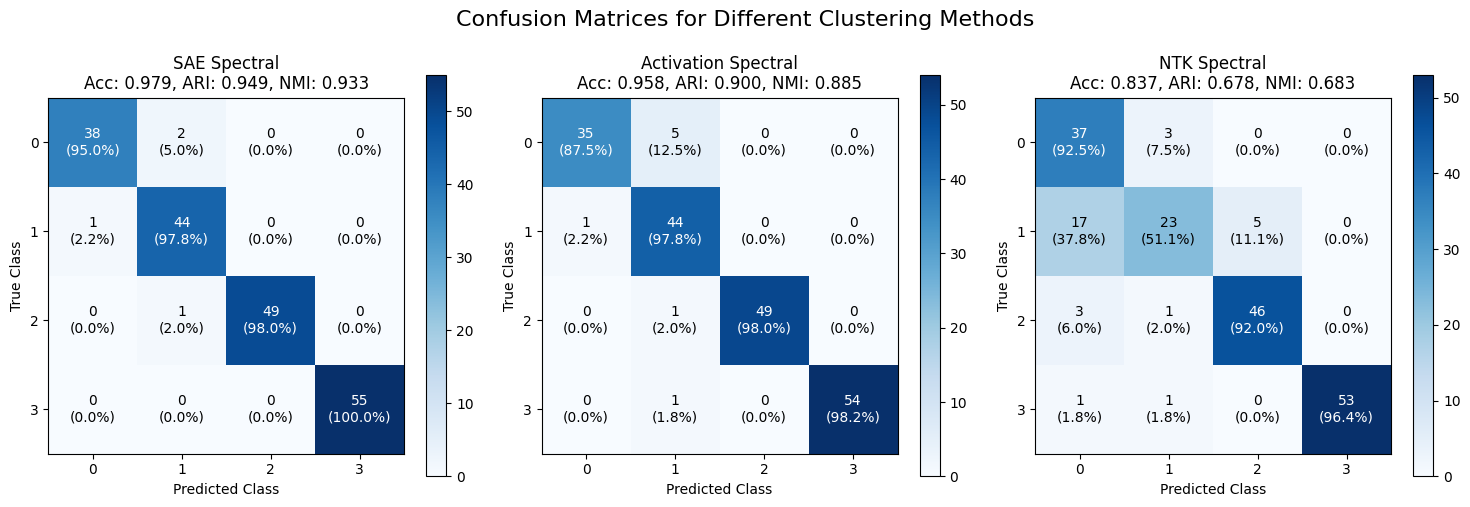

In [13]:
for i, prompt in enumerate(test_prompts):
    sae_aggregation_matrix[i] = torch.nn.functional.normalize(model_features_matrix[i], p=2, dim=0).mean(dim=0)
    activation_aggregation_matrix[i] = torch.nn.functional.normalize(model_activations_matrix[i], p=2, dim=0).mean(dim=0)

normalize_and_compute_clusters(sae_aggregation_matrix, activation_aggregation_matrix, ntk_matrix)

# This method first takes the mean over the tokens, and then normalizes the features and activations.
# In this case, SAE obtains a similar performance with NTK

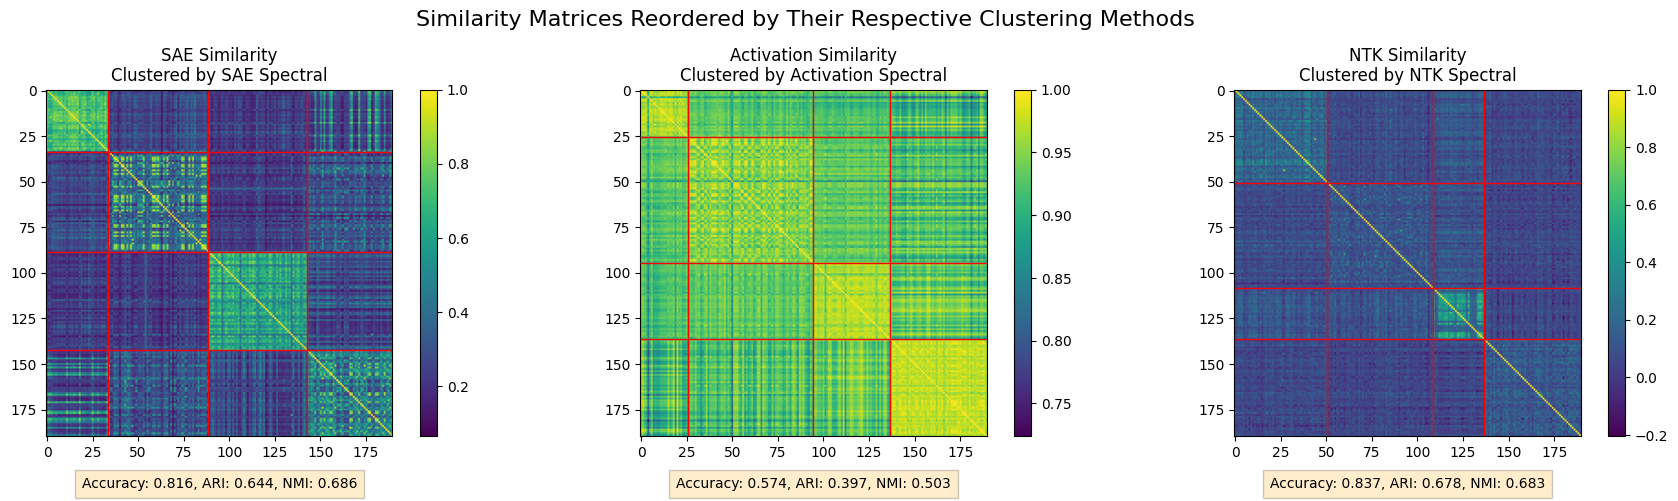

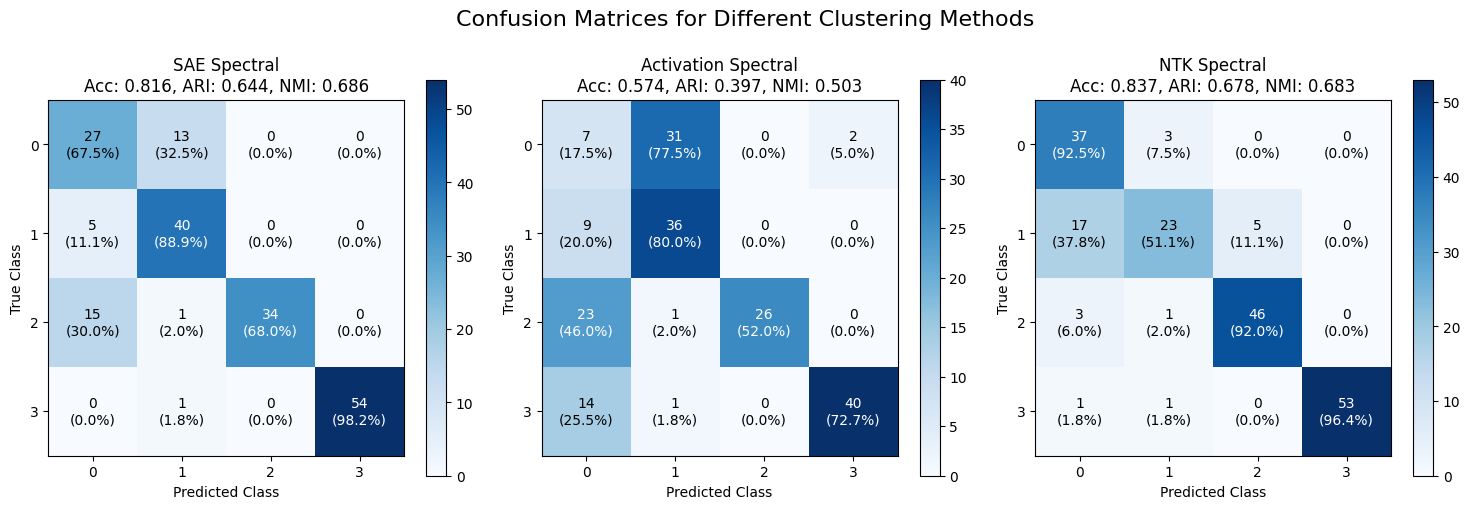

In [14]:
for i, prompt in enumerate(test_prompts):
    sae_aggregation_matrix[i] = torch.nn.functional.normalize(model_features_matrix[i].mean(dim=0), p=2, dim=0)
    activation_aggregation_matrix[i] = torch.nn.functional.normalize(model_activations_matrix[i].mean(dim=0), p=2, dim=0)

    
normalize_and_compute_clusters(sae_aggregation_matrix, activation_aggregation_matrix, ntk_matrix)

# this method first takes the maximum over the tokens, and then normalizes the features and activations.
# SAE has very high performance, and activation fails to cluster the data.

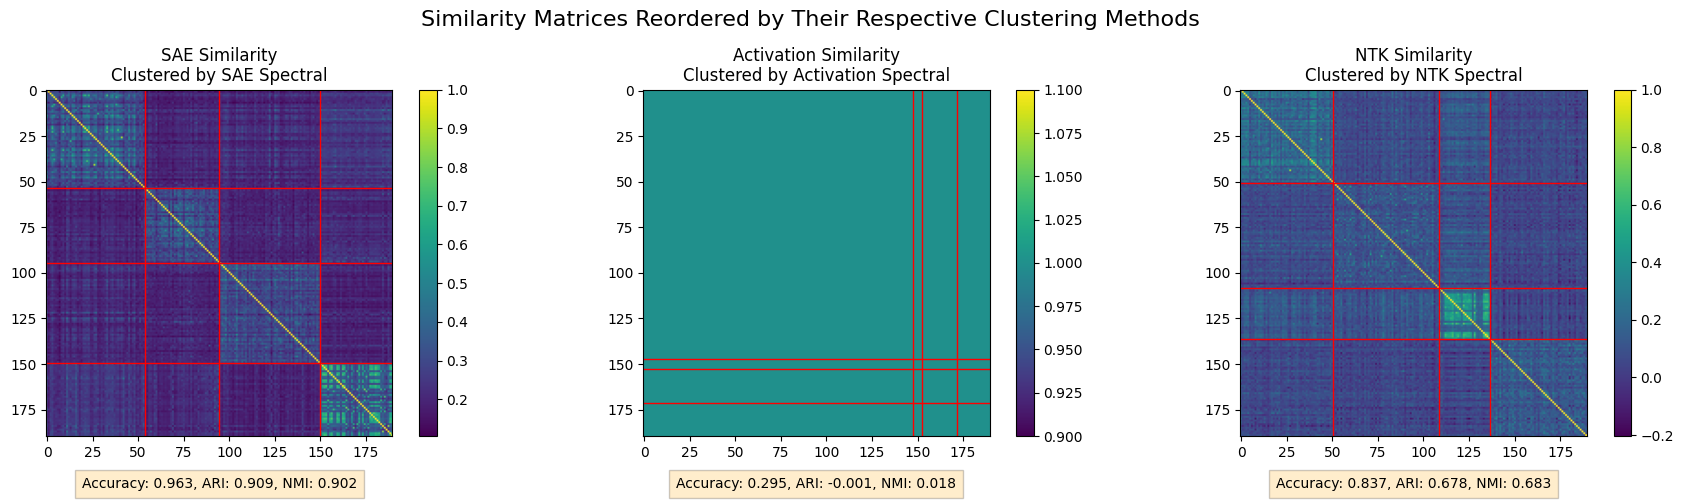

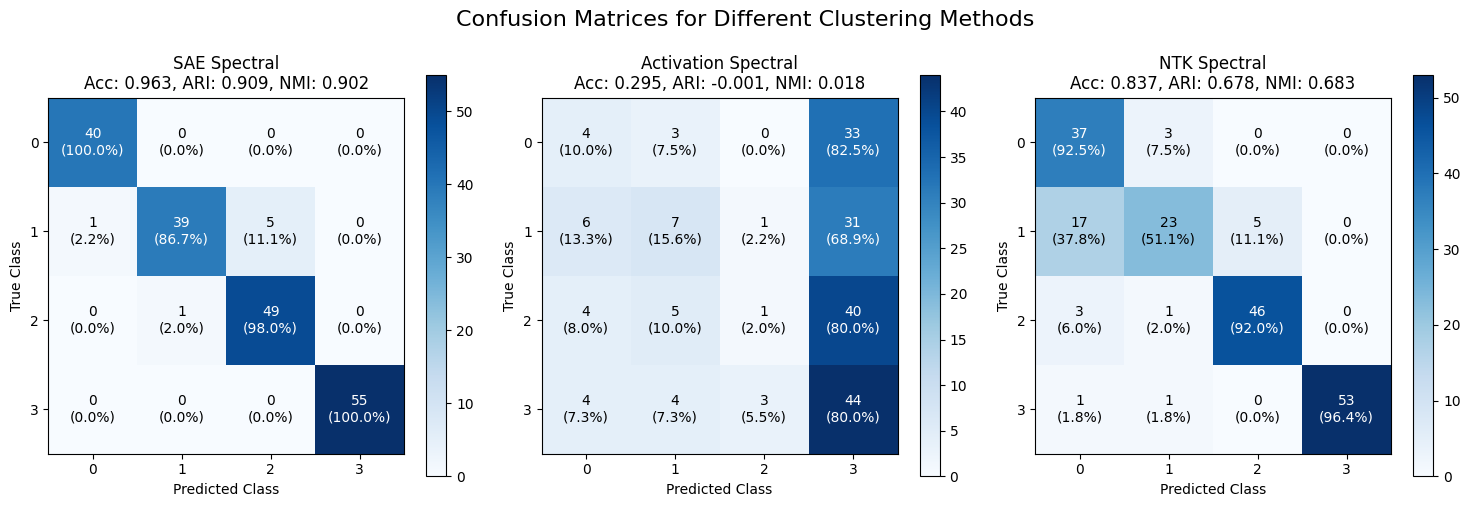

In [15]:
for i, prompt in enumerate(test_prompts):
    sae_aggregation_matrix[i] = torch.nn.functional.normalize(model_features_matrix[i].amax(dim=0), p=2, dim=0)
    activation_aggregation_matrix[i] = torch.nn.functional.normalize(model_activations_matrix[i].amax(dim=0), p=2, dim=0)


normalize_and_compute_clusters(sae_aggregation_matrix, activation_aggregation_matrix, ntk_matrix)